# Phân tích Đa biến, Mối tương quan & Đa cộng tuyến (Multivariate & Correlation)

## Khảo sát mối quan hệ giữa các đặc trưng với nhau và giữa các đặc trưng với giá nhà:

### 1.Ma trận tương quan

Tương quan với SalePrice:
SalePrice       1.000
OverallQual     0.791
TotalSF         0.782
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
Name: SalePrice, dtype: float64


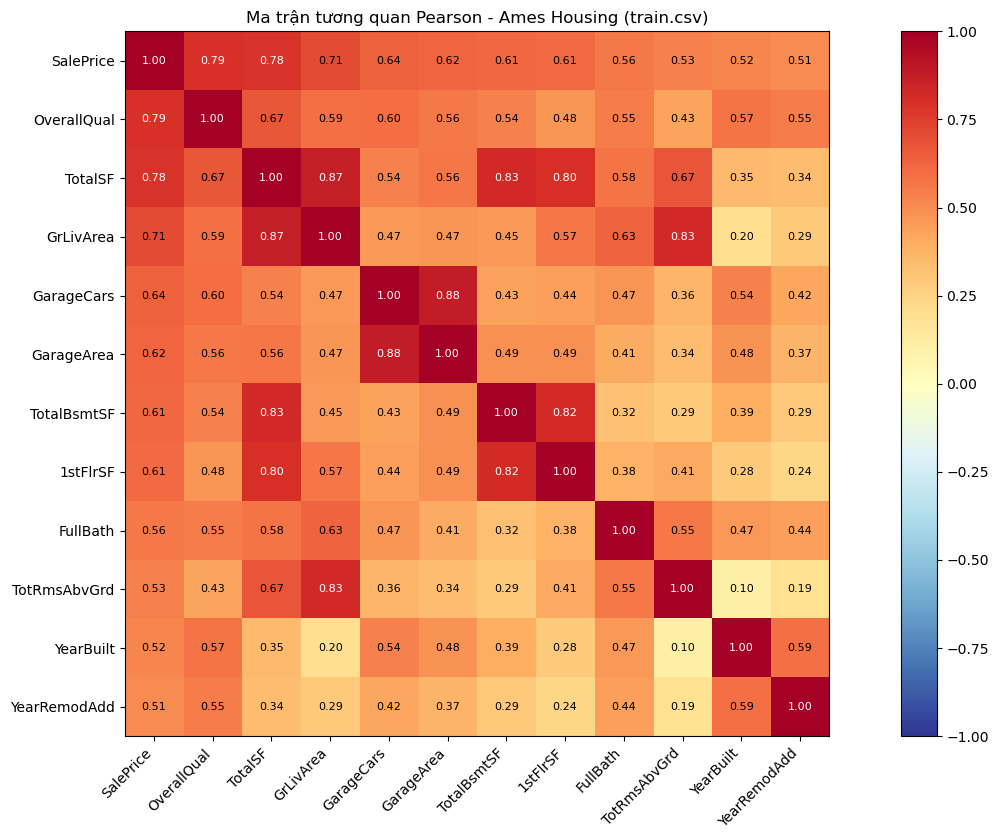

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu (đặt train.csv cùng thư mục với file .py, hoặc sửa đường dẫn)
df = pd.read_csv("data/train.csv")

# 2. Tạo biến TotalSF = diện tích tầng hầm + tầng 1 + tầng 2
df["TotalSF"] = df["TotalBsmtSF"].fillna(0) + df["1stFlrSF"] + df["2ndFlrSF"]

# 3. Chọn các đặc trưng cần khảo sát
cols = [
    "SalePrice", "OverallQual", "TotalSF", "GrLivArea",
    "GarageCars", "GarageArea", "TotalBsmtSF", "1stFlrSF",
    "FullBath", "TotRmsAbvGrd", "YearBuilt", "YearRemodAdd",
]

# 4. Tính ma trận tương quan Pearson
corr = df[cols].corr()
print("Tương quan với SalePrice:")
print(corr["SalePrice"].sort_values(ascending=False).round(3))

# 5. Vẽ heatmap
fig, ax = plt.subplots(figsize=(15, 8.5))
im = ax.imshow(corr, cmap="RdYlBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

# Ghi giá trị r vào từng ô
for i in range(len(cols)):
    for j in range(len(cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(val) > 0.75 else "black")

plt.colorbar(im, fraction=0.046)
ax.set_title("Ma trận tương quan Pearson - Ames Housing (train.csv)")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=140)
plt.show()

|cặp|r|nhận xét|
|---|---|---|
|GarageCars và GarageArea|8.7|Hai biến gần như đo cùng một thứ.|
|GrLivArea và TotalSF|8.7|TotalSF chứa GrLivArea|
|TotalBsmtSF và TotalSF|8.3|tầng hàm thường bằng với tổng diện tích|
|TotRmsAbvGrd và GrLivArea|8.3|Diện tích lớn thì nhiều phòng.|
|1stFlrSF và TotalBsmtSF |8.2|Tầng hầm thường có diện tích bằng tầng 1.|
|1stFlrSF và TotalSF |8.0|tầng 1 thường bằng với tổng diện tích|





## 2.Dùng Pivot Table và biểu đồ hộp (Boxplot) để kiểm tra giá nhà trung vị theo từng vị trí 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/train.csv")

# ---------- 1. PIVOT TABLE ----------
def make_pivot(col):
    pv = pd.pivot_table(df, index=col, values="SalePrice",
                        aggfunc=["count", "median", "mean", "min", "max"])
    pv.columns = ["Count", "Median", "Mean", "Min", "Max"]
    return pv.sort_values("Median", ascending=False)

pv_nb = make_pivot("Neighborhood")
pv_sc = make_pivot("SaleCondition")
print("=== Neighborhood ===");  print(pv_nb.round(0))
print("\n=== SaleCondition ==="); print(pv_sc.round(0))
pv_nb.to_csv("pivot_neighborhood.csv")
pv_sc.to_csv("pivot_salecondition.csv")

# ---------- 2. BOXPLOT ----------
overall = df["SalePrice"].median()

def boxplot(col, fname, title, figsize):
    order = df.groupby(col)["SalePrice"].median().sort_values(ascending=False).index
    data = [df.loc[df[col] == k, "SalePrice"] / 1000 for k in order]
    fig, ax = plt.subplots(figsize=figsize)
    bp = ax.boxplot(data, labels=order, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5),
                    flierprops=dict(marker="o", markersize=3, alpha=0.5))
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor("#F30CB5" if i < 3 else "#76B1D8")
        patch.set_alpha(0.8)
    ax.axhline(overall / 1000, color="red", linestyle="--", linewidth=1,
               label=f"Trung vị toàn bộ = {overall/1000:.0f}k")
    ax.set_ylabel("SalePrice (nghìn USD)")
    ax.set_title(title)
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(fname, dpi=140)
    plt.close()
    plt.show()

boxplot("Neighborhood", "boxplot_neighborhood.png",
        "Giá nhà theo Neighborhood (sắp xếp theo trung vị giảm dần)", (14, 6.5))
boxplot("SaleCondition", "boxplot_salecondition.png",
        "Giá nhà theo SaleCondition", (8, 5.5))

=== Neighborhood ===
              Count    Median      Mean     Min     Max
Neighborhood                                           
NridgHt          77  315000.0  316271.0  154000  611657
NoRidge          41  301500.0  335295.0  190000  755000
StoneBr          25  278000.0  310499.0  170000  556581
Timber           38  228475.0  242247.0  137500  378500
Somerst          86  225500.0  225380.0  144152  423000
Veenker          11  218000.0  238773.0  162500  385000
Crawfor          51  200624.0  210625.0   90350  392500
ClearCr          28  200250.0  212565.0  130000  328000
CollgCr         150  197200.0  197966.0  110000  424870
Blmngtn          17  191000.0  194871.0  159895  264561
NWAmes           73  182900.0  189050.0   82500  299800
Gilbert          79  181000.0  192855.0  141000  377500
SawyerW          59  179900.0  186556.0   76000  320000
Mitchel          49  153500.0  156270.0   84500  271000
NPkVill           9  146000.0  142694.0  127500  155000
NAmes           225  140000

C:\Users\HOANG PHUC\AppData\Local\Temp\ipykernel_19992\65979447.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True,
C:\Users\HOANG PHUC\AppData\Local\Temp\ipykernel_19992\65979447.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, patch_artist=True,


#### Nhân xét:
- NridgHt,NoRidge,StoneBr có giá trị vượt trội
- trên lệch giữa đắt và rẻ khá lớn: lớn nhất 315000 và nhỏ nhất 88000 gấp đến 3.6 lần
- NoRidge có giá trị trung vị (301500.0) khá lệch với giá trị trung bình (335295.0) trên lệch đến 33.795 khá cao